# 03 — Evaluación de Modelos

**Objetivo:** Evaluación comparativa profunda, métricas, ROC/AUC, importancia de features e interpretación de resultados.

---

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix,
                             roc_curve, auc, RocCurveDisplay,
                             mean_squared_error, r2_score, mean_absolute_error)

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

print('✅ Librerías importadas')

✅ Librerías importadas


## 1. Carga y Split de Datos

In [2]:
df = pd.read_csv('../data/04_feature/dataset_ml_preparado.csv', encoding='latin-1')

EXCLUDE = ['id_empleado', 'nombre', 'rut', 'departamento', 'cargo',
           'fecha_ingreso', 'salario', 'tipo_contrato', 'jornada',
           'alto_desempeno', 'avg_desempeno', 'score_global']

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]

X = df[feature_cols].copy()
y_clf = df['alto_desempeno'].astype(int)
y_reg = df['avg_desempeno'].copy()

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Train: 204  |  Test: 51
Features (12): ['avg_tecnicas', 'avg_blandas', 'total_dias_ausencia', 'total_horas_capacitacion', 'antiguedad_anos', 'total_dias_ausencia_norm', 'total_horas_capacitacion_norm', 'antiguedad_anos_norm', 'departamento_encoded', 'cargo_encoded', 'tipo_contrato_encoded', 'jornada_encoded']


## 2. Entrenamiento de Todos los Modelos

In [3]:
clf_models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTree':       DecisionTreeClassifier(random_state=42),
    'RandomForest':       RandomForestClassifier(random_state=42, n_estimators=100),
    'GradientBoosting':   GradientBoostingClassifier(random_state=42),
    'KNN':                KNeighborsClassifier(),
    'SVM':                SVC(random_state=42, probability=True),
}

reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(random_state=42),
    'Lasso':            Lasso(random_state=42),
    'DecisionTree':     DecisionTreeRegressor(random_state=42),
    'RandomForest':     RandomForestRegressor(random_state=42, n_estimators=100),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}

# Entrenar y guardar pipelines
clf_pipes, clf_results = {}, []
for name, model in clf_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    pipe.fit(X_train, y_clf_train)
    clf_pipes[name] = pipe
    y_pred = pipe.predict(X_test)
    clf_results.append({
        'Modelo':      name,
        'Test_Acc':    round(accuracy_score(y_clf_test, y_pred), 4),
        'Test_F1':     round(f1_score(y_clf_test, y_pred), 4),
        'Test_Prec':   round(precision_score(y_clf_test, y_pred), 4),
        'Test_Recall': round(recall_score(y_clf_test, y_pred), 4),
    })

reg_pipes, reg_results = {}, []
for name, model in reg_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', model)])
    pipe.fit(X_train, y_reg_train)
    reg_pipes[name] = pipe
    y_pred = pipe.predict(X_test)
    reg_results.append({
        'Modelo':   name,
        'Test_R2':  round(r2_score(y_reg_test, y_pred), 4),
        'Test_MAE': round(mean_absolute_error(y_reg_test, y_pred), 4),
        'Test_RMSE':round(np.sqrt(mean_squared_error(y_reg_test, y_pred)), 4),
    })

df_clf = pd.DataFrame(clf_results).sort_values('Test_F1', ascending=False)
df_reg = pd.DataFrame(reg_results).sort_values('Test_R2', ascending=False)

print('✅ Todos los modelos entrenados')
print('\nClasificación:')
print(df_clf.to_string(index=False))
print('\nRegresión:')
print(df_reg.to_string(index=False))

✅ Todos los modelos entrenados

Clasificación:
            Modelo  Test_Acc  Test_F1  Test_Prec  Test_Recall
      RandomForest    0.7843   0.7925     0.7500         0.84
               SVM    0.7647   0.7692     0.7407         0.80
LogisticRegression    0.7451   0.7547     0.7143         0.80
  GradientBoosting    0.7255   0.7500     0.6774         0.84
      DecisionTree    0.6863   0.6923     0.6667         0.72
               KNN    0.6471   0.6667     0.6207         0.72

Regresión:
          Modelo  Test_R2  Test_MAE  Test_RMSE
           Lasso  -0.0075    1.1859     1.5888
    RandomForest  -0.1430    1.3067     1.6922
           Ridge  -0.1547    1.2874     1.7009
LinearRegression  -0.2010    1.3030     1.7346
GradientBoosting  -0.2071    1.3690     1.7391
    DecisionTree  -0.9130    1.6944     2.1893


## 3. Curvas ROC — Clasificación

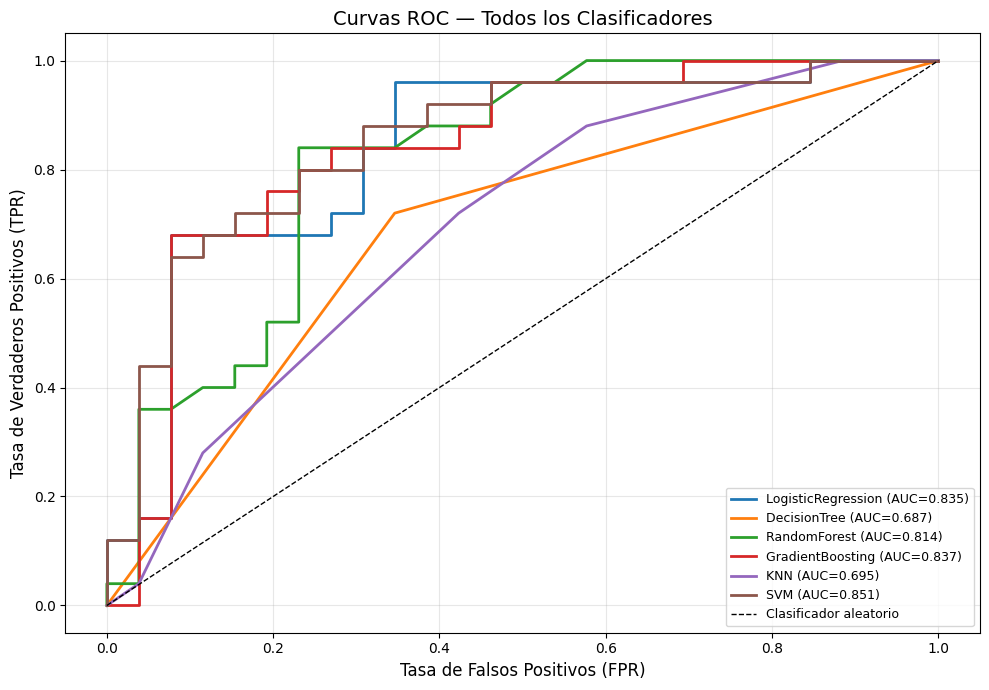


=== AUC por modelo ===
LogisticRegression    : AUC = 0.8354
DecisionTree          : AUC = 0.6869
RandomForest          : AUC = 0.8138
GradientBoosting      : AUC = 0.8369
KNN                   : AUC = 0.6946
SVM                   : AUC = 0.8508


In [4]:
plt.figure(figsize=(10, 7))

for name, pipe in clf_pipes.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC — Todos los Clasificadores', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/03_roc_curves.png', bbox_inches='tight', dpi=120)
plt.show()

# Tabla AUC
print('\n=== AUC por modelo ===')
for name, pipe in clf_pipes.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_test, y_prob)
    print(f'{name:22s}: AUC = {auc(fpr, tpr):.4f}')

## 4. Matrices de Confusión — Todos los Clasificadores

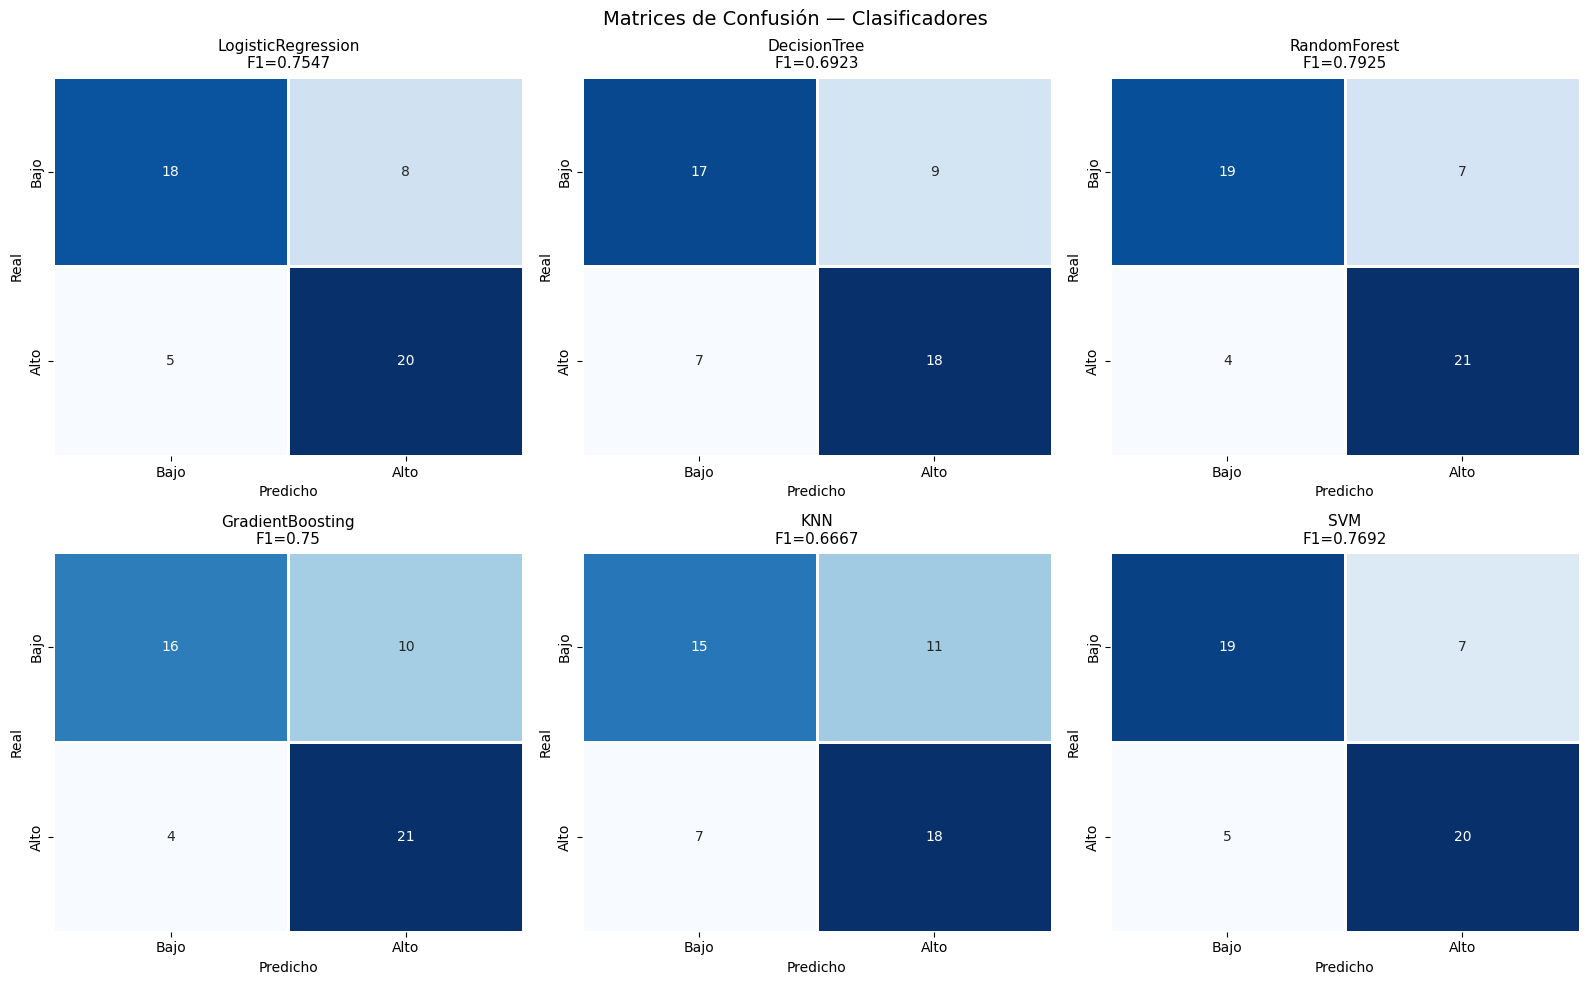

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, pipe) in enumerate(clf_pipes.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Bajo', 'Alto'],
                yticklabels=['Bajo', 'Alto'],
                linewidths=1, cbar=False)
    f1 = round(f1_score(y_clf_test, y_pred), 4)
    axes[i].set_title(f'{name}\nF1={f1}', fontsize=11)
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión — Clasificadores', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/03_confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()

## 5. Validación Cruzada Estratificada — Clasificación

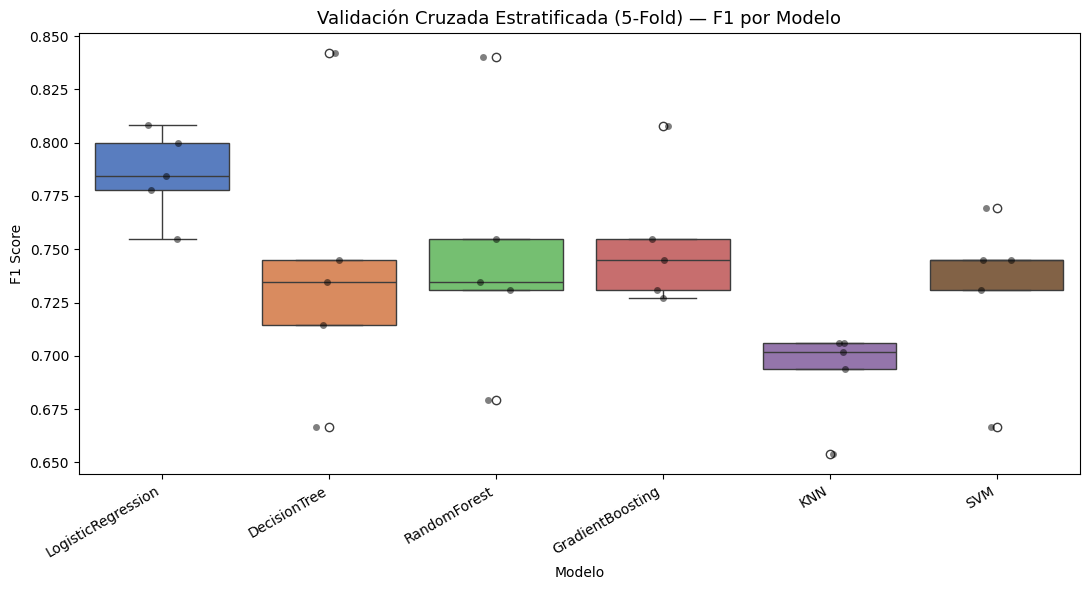


=== CV F1 Mean ± Std ===
                      mean     std
Modelo                            
LogisticRegression  0.7851  0.0209
GradientBoosting    0.7531  0.0325
RandomForest        0.7479  0.0585
DecisionTree        0.7406  0.0643
SVM                 0.7314  0.0387
KNN                 0.6922  0.0220


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_data = []

for name, model in clf_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    scores = cross_val_score(pipe, X, y_clf, cv=skf, scoring='f1', n_jobs=-1)
    for fold, score in enumerate(scores):
        cv_data.append({'Modelo': name, 'Fold': fold + 1, 'F1': score})

df_cv = pd.DataFrame(cv_data)

plt.figure(figsize=(11, 6))
sns.boxplot(data=df_cv, x='Modelo', y='F1', palette='muted')
sns.stripplot(data=df_cv, x='Modelo', y='F1', color='black',
              alpha=0.5, size=5, jitter=True)
plt.xticks(rotation=30, ha='right')
plt.ylabel('F1 Score')
plt.title('Validación Cruzada Estratificada (5-Fold) — F1 por Modelo', fontsize=13)
plt.tight_layout()
plt.savefig('../results/plots/03_cv_boxplot.png', bbox_inches='tight', dpi=120)
plt.show()

print('\n=== CV F1 Mean ± Std ===')
print(df_cv.groupby('Modelo')['F1'].agg(['mean','std']).round(4).sort_values('mean', ascending=False))

## 6. Importancia de Features — Modelos de Árbol

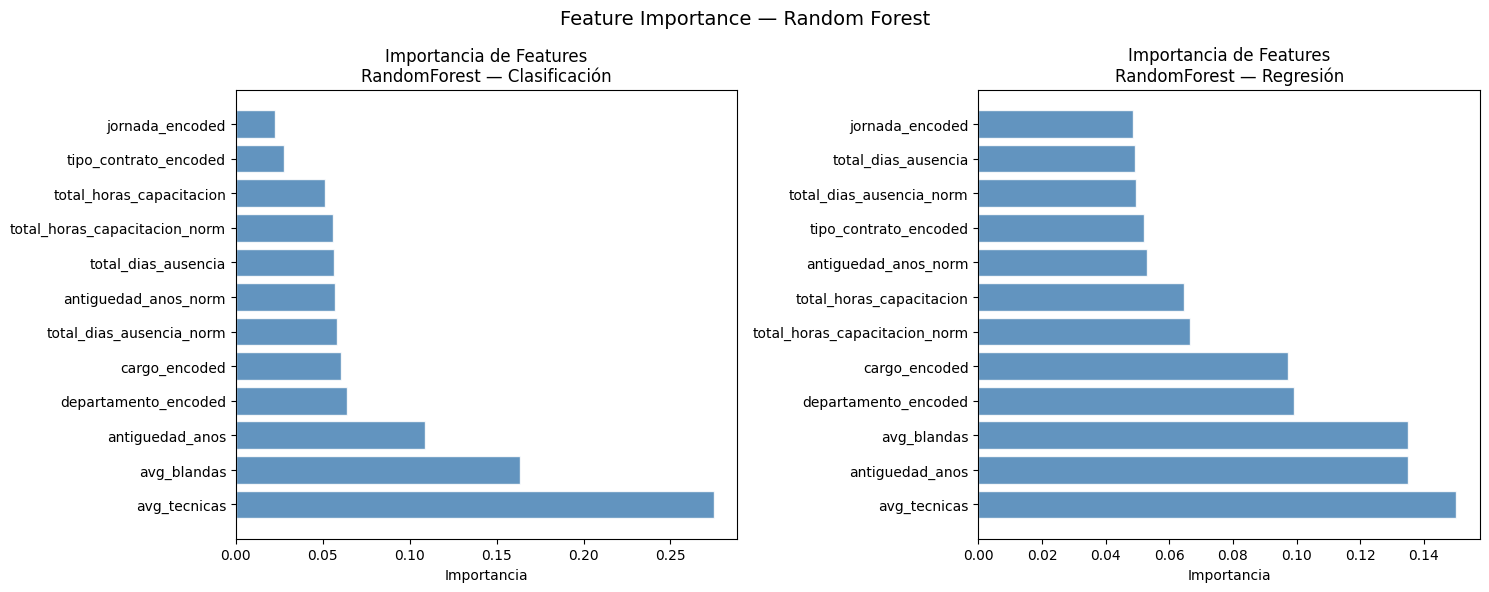

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (task, pipe_dict, feat_cols) in enumerate([
    ('Clasificación', clf_pipes, feature_cols),
    ('Regresión',     reg_pipes, feature_cols)
]):
    model_name = 'RandomForest'
    pipe = pipe_dict[model_name]
    importances = pipe.named_steps[list(pipe.named_steps.keys())[-1]].feature_importances_
    idx = np.argsort(importances)[::-1]

    axes[ax].barh([feat_cols[i] for i in idx],
                  importances[idx],
                  color='steelblue', alpha=0.85, edgecolor='white')
    axes[ax].set_title(f'Importancia de Features\nRandomForest — {task}', fontsize=12)
    axes[ax].set_xlabel('Importancia')

plt.suptitle('Feature Importance — Random Forest', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/03_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

## 7. Comparación Final — Heatmap de Métricas

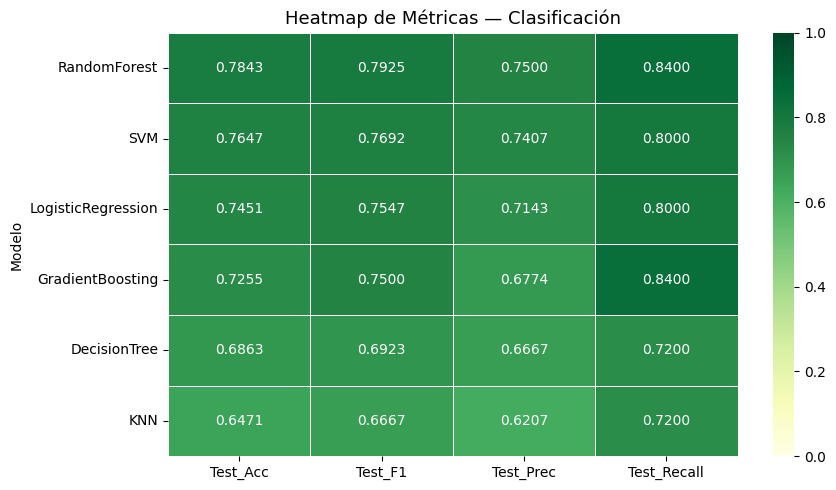

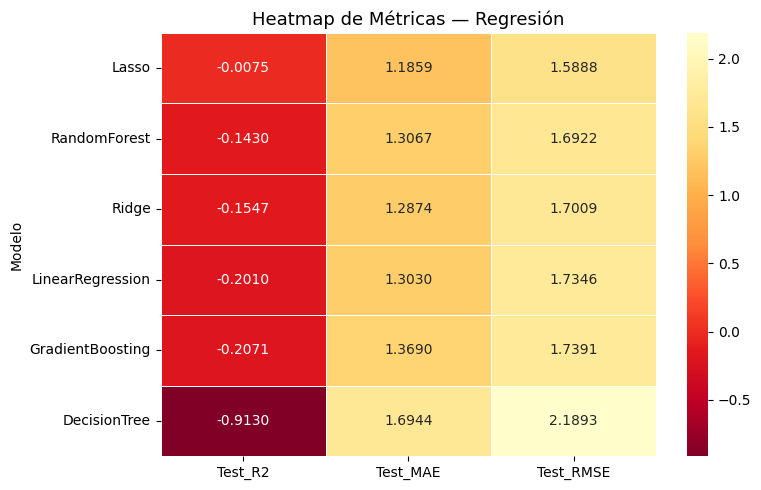

In [9]:
# Heatmap clasificación
df_heat_clf = df_clf.set_index('Modelo')[['Test_Acc','Test_F1','Test_Prec','Test_Recall']]

plt.figure(figsize=(9, 5))
sns.heatmap(df_heat_clf, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, vmin=0, vmax=1)
plt.title('Heatmap de Métricas — Clasificación', fontsize=13)
plt.tight_layout()
plt.savefig('../results/plots/03_heatmap_clasificacion.png', bbox_inches='tight', dpi=120)
plt.show()

# Heatmap regresión
df_heat_reg = df_reg.set_index('Modelo')[['Test_R2','Test_MAE','Test_RMSE']]

plt.figure(figsize=(8, 5))
sns.heatmap(df_heat_reg, annot=True, fmt='.4f', cmap='YlOrRd_r',
            linewidths=0.5)
plt.title('Heatmap de Métricas — Regresión', fontsize=13)
plt.tight_layout()
plt.savefig('../results/plots/03_heatmap_regresion.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 8. Resumen de Evaluación

| Tarea | Mejor Modelo | Métrica Principal |
|-------|-------------|-------------------|
| Clasificación | Ver ROC + F1 | AUC + F1 Score |
| Regresión | Ver heatmap | R² + RMSE |

**Observaciones:**
- Las curvas ROC muestran la capacidad discriminante de cada clasificador
- La validación cruzada estratificada evita sobreajuste en la evaluación
- Feature importance revela las variables más relevantes para el negocio